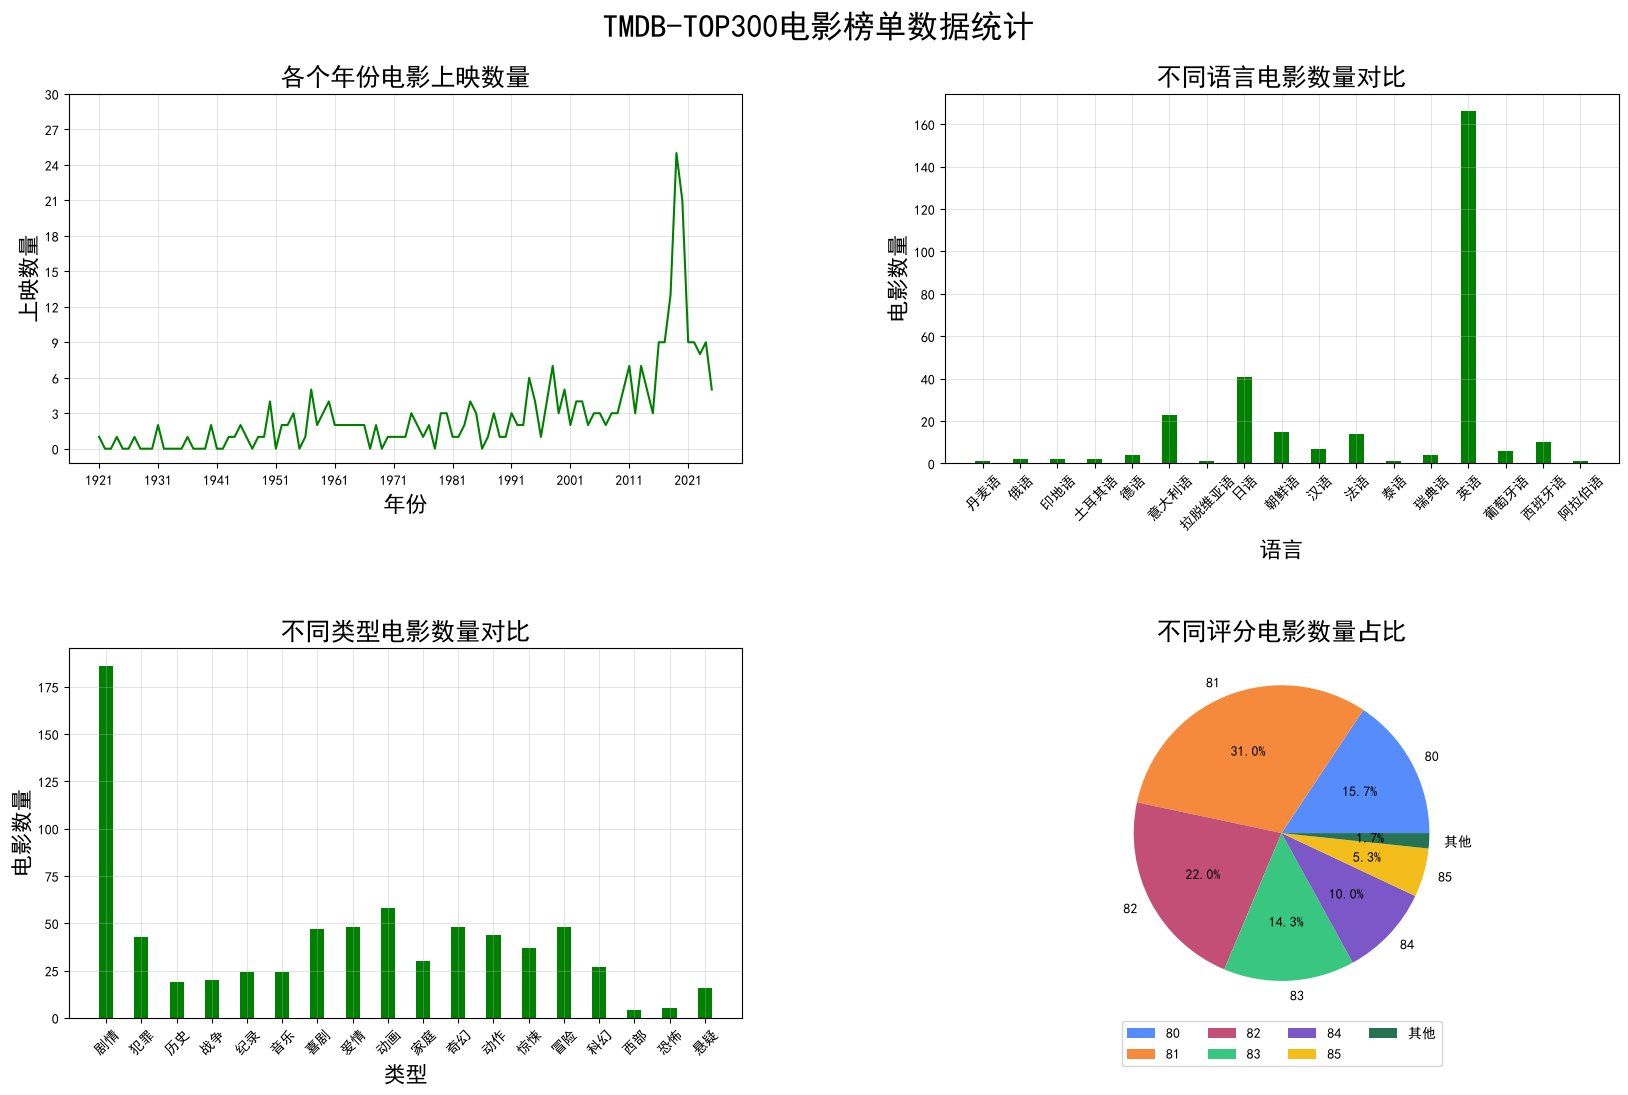

In [1]:
from pandas import Series
import pandas as pd

from matplotlib.axes import Axes
import matplotlib.pyplot as plt


plt.rcParams['font.sans-serif'] = ['SimHei'] #设置中文字体

#创建子图
fig,axes = plt.subplots(nrows = 2,ncols= 2,figsize=(20,12),dpi = 100)
fig.suptitle('TMDB-TOP300电影榜单数据统计',fontsize = 23,x=0.5,y = 0.95) # x表示水平位置  y 表示垂直位置
plt.subplots_adjust(hspace=0.5  , wspace=0.3) # 调整子图之间的间距 hspace 纵向间距 wspace 横向间距


#获取子图
axes1 : Axes = axes[0][0]
axes2 : Axes = axes[0][1]
axes3 : Axes = axes[1][0]
axes4 : Axes = axes[1][1]

#加载数据
# int64 : 整形数字 (不支持空值)
# Int64 : 整形数字 (支持空值)
# float64 : 浮点型数字 (支持空值)
data = pd.read_csv('data/movies.csv',usecols=['电影名','年份','上映时间','类型','评分','语言'],dtype={'年份':'Int64'})



# 1.统计各个年份电影上映数量
# 1.1 缺失值，异常值处理
# data.isnull().sum()
data['年份'] = data['年份'].fillna(data['上映时间'].str[0:4]) #fillna() 只处理缺失的情况，不处理有值的情况


# 1.2 分组统计
year_count = data.groupby('年份')['年份'].count()

# 1.3 组装数据
# x轴数据
min_year = year_count.index.min()
max_year = year_count.index.max()

x = [i for i in range(min_year,max_year+1)]
y = [int(year_count.get(i,0)) for i in x]

# 1.4
axes1.plot(x,y,c='g')#折线图
axes1.set_title('各个年份电影上映数量',fontsize = 18)#添加子图标题
axes1.set_xlabel('年份',fontsize = 16)#x轴标签
axes1.set_ylabel('上映数量',fontsize = 16)#y轴标签

axes1.set_xticks(x[::10])#x轴刻度
y_ticks = [i for i in range(0,31,3)]#y轴刻度
axes1.set_yticks(y_ticks)#设置y轴刻度

axes1.grid(True)


# 2.需求二 :统计对比不同语言的电影数量。(柱状图)
# 2.1 获取不同语言电影数量
language_count = data.groupby('语言')['语言'].count()

languages = language_count.index.tolist()
language_digits = language_count.values.tolist()

# 2.2 绘制柱状图
axes2.bar(languages,language_digits,color = 'g',width= 0.4)
axes2.set_title('不同语言电影数量对比',fontsize = 18)
axes2.set_xlabel('语言',fontsize = 16)
axes2.set_ylabel('电影数量',fontsize = 16)
axes2.tick_params(axis='x',rotation=45)
axes2.grid(True)


# 3. 需求三:不同类型电影数量对比

# 3.1 获取不同类型电影数量
type_count = {}
types = data['类型'].str.split(',').tolist()

for types in types:
    for type in types:
        if type in type_count:
            type_count[type]+=1
        if type not in type_count:
            type_count[type]=1
x_types = list(type_count.keys())
y_types = list(type_count.values())

# 3.2 绘制柱状图

axes3.bar(x_types,y_types,color = 'g',width= 0.4)
axes3.set_title('不同类型电影数量对比',fontsize = 18)
axes3.set_xlabel('类型',fontsize = 16)
axes3.set_ylabel('电影数量',fontsize = 16)
axes3.tick_params(axis='x',rotation=45)
axes3.grid(True)

# 4 统计不同电影盘评分占比
# 4.1 获取不同评分电影数量
rating_count = data.groupby('评分')['评分'].count()

# 合并小数据
total = rating_count.sum()
lager_data : Series = rating_count[rating_count >= total * 0.02]
small_data : Series = rating_count[rating_count < total * 0.02]

if small_data.shape[0] > 0:
    lager_data['其他'] = small_data.sum()

rating = lager_data.index.tolist()
rating_digits = lager_data.values.tolist()

# 4.2 绘制饼图
axes4.pie(rating_digits,labels=rating,autopct='%1.1f%%')
axes4.set_title('不同评分电影数量占比',fontsize = 18)
axes4.legend(loc = 'lower center',ncol  = 4,bbox_to_anchor = (0.5,-0.15))# 控制图例位置

#展示数据
#plt.savefig('data/TMAB_top300_movies_analysis.png')
plt.show()